# UNSW-NB15 Intrusion Detection — ML Pipeline
**Java 17 | Python 3.9 | PySpark 3.5**

Pipeline:
1. Environment & Spark session
2. Global constants (no hard-coded column names)
3. Load & normalise raw CSVs from HDFS
4. Preprocess — drop binary label, cast numerics, mean-fill nulls
5. Class distribution
6. Balance training classes (oversampling)
7. IQR outlier clipping
8. Feature engineering (StringIndex → OHE → VectorAssemble → StandardScale)
9. Define 5 classifiers
10. Hyperparameter tuning (TrainValidationSplit on 20 % sample)
11. Final evaluation (train + test)
12. Comparison table & chart
13. Save best full-pipeline to HDFS
14. Verify saved model

In [1]:
import sys, os, time
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.functions import col, percentile_approx, when
from pyspark.sql.types import NumericType, StringType

from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    RandomForestClassifier, DecisionTreeClassifier,
    LogisticRegression, NaiveBayes, MultilayerPerceptronClassifier,
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder

from config import (
    HADOOP_bin_path,HADOOP_HOME_path,
)

## 1 · Environment Setup

In [2]:
# Fix Python worker mismatch → prevents "worker failed to connect back"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
#os.environ["HADOOP_HOME"] = r"D:\hadoop-3.3.6"
#os.environ["PATH"]       += os.pathsep + r"D:\hadoop-3.3.6\bin"
os.environ["HADOOP_HOME"] = HADOOP_HOME_path
os.environ["PATH"]       += os.pathsep + HADOOP_bin_path
# Short local dir → avoids Windows 260-char shuffle-path crash
SPARK_LOCAL = r"C:\spark-tmp"
os.makedirs(SPARK_LOCAL, exist_ok=True)
print("PYSPARK_PYTHON →", os.environ["PYSPARK_PYTHON"])

PYSPARK_PYTHON → c:\Users\yasse\anaconda3\envs\bigdata\python.exe


## 2 · Spark Session

In [3]:
spark = (
    SparkSession.builder
    .appName("UNSW_NB15_Comparison")
    .config("spark.hadoop.dfs.client.use.datanode.hostname", "true")
    .config("spark.driver.host",        "localhost")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.memory",      "8g")
    .config("spark.executor.memory",    "3g")
    .config("spark.memory.offHeap.enabled", "true")
    .config("spark.memory.offHeap.size",    "2g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.default.parallelism",    "32")
    .config("spark.python.worker.timeout",  "120")
    .config("spark.network.timeout",        "300s")
    .config("spark.local.dir",              SPARK_LOCAL)
    .config("spark.driver.extraJavaOptions", f"-Djava.io.tmpdir={SPARK_LOCAL}")
    .config("spark.executor.extraJavaOptions", f"-Djava.io.tmpdir={SPARK_LOCAL}")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 3.5.3


## 3 · Global Constants

In [4]:

from config import (
    HADOOP_bin_path,HADOOP_HOME_path
    ,MODEL_PATH,TARGET_RAW,LABEL_COL,FEATURE_COL
    ,BINARY_LABEL,CAT_COLS,HDFS_TRAIN_CSV,HDFS_TEST_CSV

)

In [5]:
#HDFS_TRAIN_CSV = "hdfs://namenode:9005/data/unsw/UNSW_NB15_training-set.csv"
#HDFS_TEST_CSV  = "hdfs://namenode:9005/data/unsw/UNSW_NB15_testing-set.csv"
#MODEL_PATH     = "hdfs://namenode:9005/ml/unsw_nb15_final_pipeline"

# ── Column-role constants (single source of truth) ───────────────────────────
#TARGET_RAW   = "attack_cat"      # multi-class string label → used by StringIndexer
#LABEL_COL    = "label"           # numeric label produced by StringIndexer
#FEATURE_COL  = "scaledFeatures"  # final feature vector after scaling
#BINARY_LABEL = "label"           # the 0/1 binary column in the raw CSV (same name)

# Categorical columns that need StringIndex + OHE
#CAT_COLS = ["proto", "service", "state"]

# Raw columns to drop before any ML work
# BINARY_LABEL is the raw 0/1 'label' column — must be dropped so it does not
# clash with the numeric LABEL_COL that StringIndexer writes from attack_cat
RAW_ID_COLS  = ["srcip", "sport", "dstip", "dsport", "Stime", "Ltime", "id", "rate"]
DROP_COLS    = RAW_ID_COLS + [BINARY_LABEL]   # dropped in preprocess()

# Columns the VectorAssembler must never receive as numeric inputs
# (derived dynamically from CAT_COLS + role constants — no hard-coded feature list)
PIPELINE_EXCLUDE = frozenset(
    CAT_COLS
    + [f"{c}_idx" for c in CAT_COLS]
    + [f"{c}_vec" for c in CAT_COLS]
    + [TARGET_RAW, BINARY_LABEL, LABEL_COL, "features", FEATURE_COL]
)

MAX_BALANCE = 21_000   # max rows per class after oversampling

## 4 · Load & Normalise Raw Data

In [6]:
def normalize_unsw_raw(df: DataFrame) -> DataFrame:
    """
    Standardise column names across UNSW-NB15 CSV variants.
    All renames are driven by this map — no column names are hard-coded elsewhere.
    """
    rename_map = {
        # Capitalisation variants (raw files differ)
        "Spkts":    "spkts",  "Dpkts":    "dpkts",
        "Sload":    "sload",  "Dload":    "dload",
        "Sjit":     "sjit",   "Djit":     "djit",
        "Sintpkt":  "sinpkt", "Dintpkt":  "dinpkt",
        "Label":    BINARY_LABEL,       # keeps the binary 0/1 col under its constant name
        # Renamed columns
        "smeansz":     "smean",
        "dmeansz":     "dmean",
        "res_bdy_len": "response_body_len",
        "ct_src_ ltm": "ct_src_ltm",   # hidden-space variant in some raw files
    }
    # Only rename columns that actually exist (safe across all file variants)
    for old, new in rename_map.items():
        if old in df.columns:
            df = df.withColumnRenamed(old, new)
    return df


df_train_raw = spark.read.csv(HDFS_TRAIN_CSV, header=True, inferSchema=True)
df_test_raw  = spark.read.csv(HDFS_TEST_CSV,  header=True, inferSchema=True)

df_train_raw = normalize_unsw_raw(df_train_raw)
df_test_raw  = normalize_unsw_raw(df_test_raw)

print("Train columns:", df_train_raw.columns)
print("Test  columns:", df_test_raw.columns)
df_train_raw.show(3)

Train columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
Test  columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_sr

## 5 · Preprocess

In [7]:
def preprocess(df: DataFrame) -> DataFrame:
    """
    1. Drop raw identifier columns AND the binary label column.
       attack_cat is kept — the pipeline's StringIndexer reads it to create LABEL_COL.
    2. Detect numeric columns dynamically from the schema (no hard-coded list).
    3. Cast all numerics to double.
    4. Mean-fill nulls in a single aggregation pass.
    5. Fill categorical nulls with 'Unknown'.
    """
    # Step 1 — drop unwanted columns (only those that are actually present)
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(*cols_to_drop)

    # Step 2 — discover numeric columns dynamically
    numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]

    # Step 3 — cast to double
    for c in numeric_cols:
        df = df.withColumn(c, col(c).cast("double"))

    # Step 4 — mean-fill numeric nulls (single aggregation pass)
    means = df.select([F.mean(col(c)).alias(c) for c in numeric_cols]).collect()[0].asDict()
    df = df.fillna(means)

    # Step 5 — fill categorical nulls
    cat_present = [c for c in CAT_COLS if c in df.columns]
    df = df.fillna({c: "Unknown" for c in cat_present})
    if TARGET_RAW in df.columns:
        df = df.fillna({TARGET_RAW: "Normal"})

    return df


df_train_clean = preprocess(df_train_raw)
df_test_clean  = preprocess(df_test_raw)

print(f"Train rows : {df_train_clean.count():,}")
print(f"Test  rows : {df_test_clean.count():,}")
print("Train cols :", df_train_clean.columns)

Train rows : 82,332
Test  rows : 175,341
Train cols : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat']


## 6 · Class Distribution


[Train] Class distribution:
+--------------+-----+
|attack_cat    |count|
+--------------+-----+
|Normal        |37000|
|Generic       |18871|
|Exploits      |11132|
|Fuzzers       |6062 |
|DoS           |4089 |
|Reconnaissance|3496 |
|Analysis      |677  |
|Backdoor      |583  |
|Shellcode     |378  |
|Worms         |44   |
+--------------+-----+



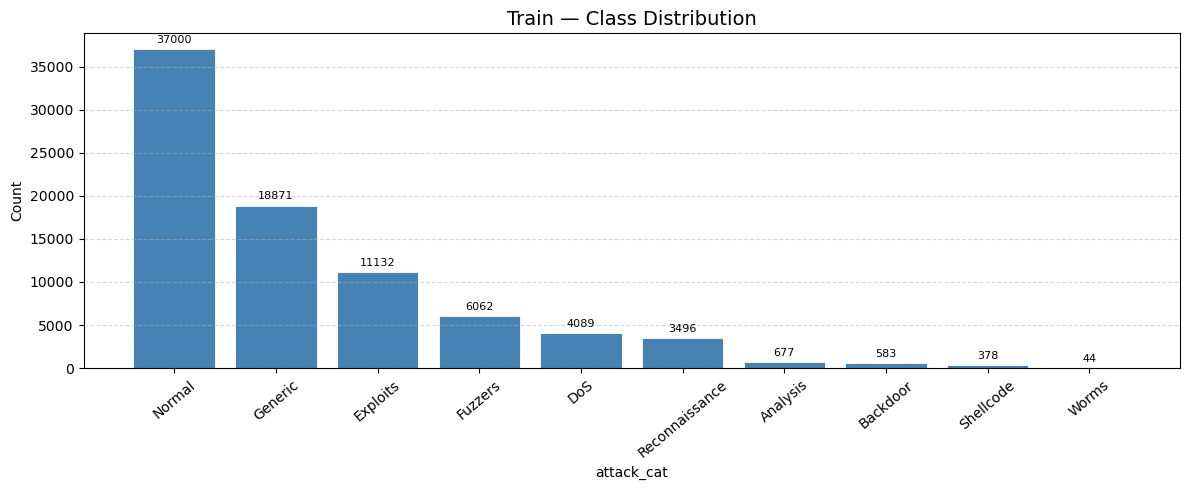

In [8]:
def draw_distribution(df: DataFrame, column: str, title: str = "Class Distribution") -> None:
    dist = df.groupBy(column).count().toPandas().sort_values("count", ascending=False)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(dist[column], dist["count"], color="steelblue", edgecolor="white", linewidth=0.6)
    ax.bar_label(bars, fmt="%d", fontsize=8, padding=3)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=40)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


print("\n[Train] Class distribution:")
df_train_clean.groupBy(TARGET_RAW).count().orderBy("count", ascending=False).show(truncate=False)
draw_distribution(df_train_clean, TARGET_RAW, "Train — Class Distribution")

## 7 · Balance Training Classes (Oversampling)

Original rows : 82,332
Balanced rows : 209,741


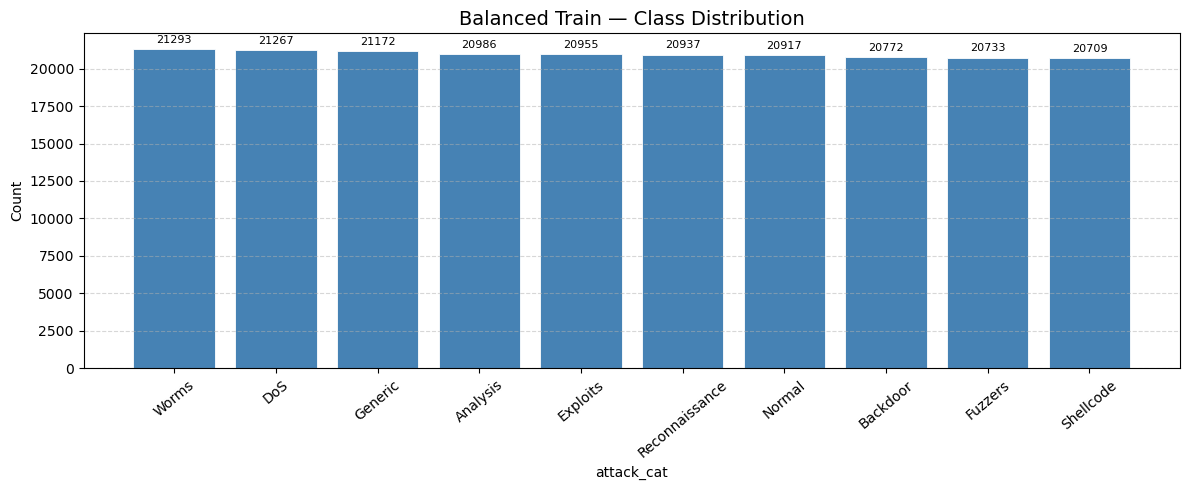

In [9]:
counts = df_train_clean.groupBy(TARGET_RAW).count().collect()

balanced_dfs = []
for row in counts:
    cls_df = df_train_clean.filter(col(TARGET_RAW) == row[TARGET_RAW])
    ratio  = MAX_BALANCE / row["count"]
    balanced_dfs.append(cls_df.sample(withReplacement=True, fraction=ratio, seed=42))

df_balanced = reduce(DataFrame.union, balanced_dfs)
print(f"Original rows : {df_train_clean.count():,}")
print(f"Balanced rows : {df_balanced.count():,}")
draw_distribution(df_balanced, TARGET_RAW, "Balanced Train — Class Distribution")

## 8 · IQR Outlier Clipping

Before clipping:


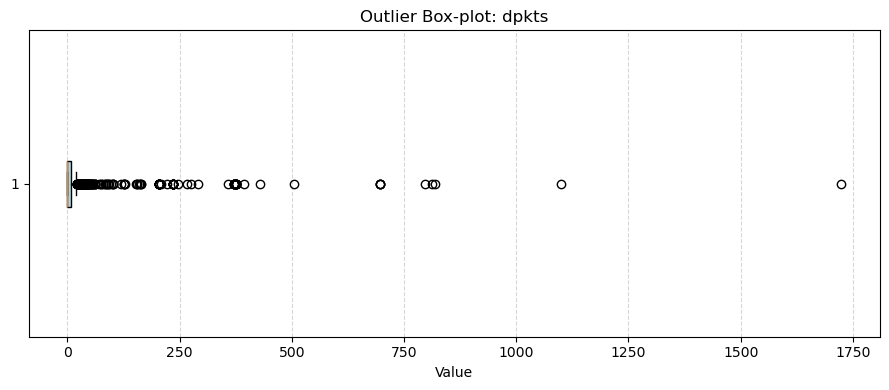

  [dpkts]  lower=-12.00  upper=20.00  outliers=14,115

After clipping:


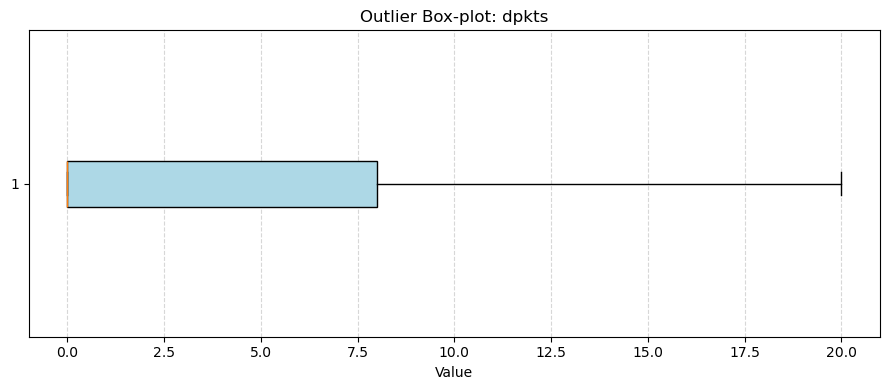

  [dpkts]  lower=-12.00  upper=20.00  outliers=0
IQR clipping done.


In [10]:
def iqr_clip(df: DataFrame, columns=None) -> DataFrame:
    """Clip each numeric column to [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    if columns is None:
        columns = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float")]
    for c in columns:
        df = df.withColumn(c, col(c).cast("double"))
        q1, q3 = df.select(percentile_approx(c, [0.25, 0.75]).alias("p")).collect()[0]["p"]
        iqr    = q3 - q1
        lower  = q1 - 1.5 * iqr
        upper  = q3 + 1.5 * iqr
        df = df.withColumn(
            c, when(col(c) < lower, lower).when(col(c) > upper, upper).otherwise(col(c))
        )
    return df


def plot_outlier_box(df: DataFrame, column: str) -> None:
    stats = df.select(F.percentile_approx(column, [0.25, 0.5, 0.75])).collect()[0][0]
    q1, _, q3 = stats
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    n_out  = df.filter((col(column) < lower) | (col(column) > upper)).count()
    sample = df.sample(False, 0.01).select(column).toPandas()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.boxplot(sample[column], vert=False, patch_artist=True,
               boxprops=dict(facecolor="lightblue"))
    ax.set_title(f"Outlier Box-plot: {column}")
    ax.set_xlabel("Value")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    print(f"  [{column}]  lower={lower:.2f}  upper={upper:.2f}  outliers={n_out:,}")


# Numeric features discovered dynamically — exclude categoricals and target
numeric_features = [
    c for c, t in df_balanced.dtypes
    if t in ("int", "bigint", "double", "float") and c not in PIPELINE_EXCLUDE
]

print("Before clipping:")
plot_outlier_box(df_balanced, "dpkts")

# Clip balanced train ONLY (test set is left unclipped — bounds come from train)
df_balanced = iqr_clip(df_balanced, numeric_features)

print("\nAfter clipping:")
plot_outlier_box(df_balanced, "dpkts")
print("IQR clipping done.")

## 9 · Feature Engineering Pipeline

In [11]:
def build_feature_pipeline(df_schema_cols: list):
    """
    Build an unfitted (feature_pipeline, label_indexer) pair.

    Numeric feature columns are discovered dynamically from df_schema_cols
    by excluding PIPELINE_EXCLUDE — no column list is hard-coded here.
    """
    # Numeric columns = everything NOT in the exclude set
    num_cols = [c for c in df_schema_cols if c not in PIPELINE_EXCLUDE]

    indexers  = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
                 for c in CAT_COLS]
    encoders  = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec",
                               dropLast=False, handleInvalid="keep")
                 for c in CAT_COLS]
    assembler = VectorAssembler(
        inputCols=num_cols + [f"{c}_vec" for c in CAT_COLS],
        outputCol="features", handleInvalid="keep",
    )
    scaler = StandardScaler(inputCol="features", outputCol=FEATURE_COL, withMean=False)

    # label_indexer converts attack_cat (string) → LABEL_COL (numeric)
    label_indexer = StringIndexer(inputCol=TARGET_RAW, outputCol=LABEL_COL, handleInvalid="keep")

    feature_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])
    return feature_pipeline, label_indexer


# Fit on balanced train ONLY, then transform both splits
feature_pipeline, label_indexer = build_feature_pipeline(df_balanced.columns)

feat_model  = feature_pipeline.fit(df_balanced)
label_model = label_indexer.fit(df_balanced)


def apply_pipeline(df: DataFrame) -> DataFrame:
    """Apply feature + label pipeline and keep only the two ML columns."""
    return (
        label_model.transform(feat_model.transform(df))
        .select(FEATURE_COL, LABEL_COL)
    )


df_train_pro = apply_pipeline(df_balanced).cache()
df_test_pro  = apply_pipeline(df_test_clean).cache()

n_train = df_train_pro.count()
n_test  = df_test_pro.count()
train_feat_size = df_train_pro.select(FEATURE_COL).first()[0].size
test_feat_size  = df_test_pro.select(FEATURE_COL).first()[0].size

print(f"Train rows         : {n_train:,}")
print(f"Test  rows         : {n_test:,}")
print(f"Feature size match : {train_feat_size == test_feat_size}  "
      f"(train={train_feat_size}, test={test_feat_size})  ← must be True")

train_labels = sorted(r[0] for r in df_train_pro.select(LABEL_COL).distinct().collect())
test_labels  = sorted(r[0] for r in df_test_pro.select(LABEL_COL).distinct().collect())
print(f"Train labels : {train_labels}")
print(f"Test  labels : {test_labels}")

Train rows         : 209,741
Test  rows         : 175,341
Feature size match : True  (train=195, test=195)  ← must be True
Train labels : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
Test  labels : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]


## 10 · Define Classifiers

In [12]:
num_classes  = int(df_train_pro.select(LABEL_COL).distinct().count())
num_features = int(df_train_pro.select(FEATURE_COL).first()[0].size)
mlpc_layers  = [num_features, 64, 32, num_classes]
print(f"Classes={num_classes}  Features={num_features}  MLPC layers={mlpc_layers}")

models = {
    "RandomForest": RandomForestClassifier(
        featuresCol=FEATURE_COL, labelCol=LABEL_COL,
        numTrees=200, maxDepth=20, minInstancesPerNode=12,
        featureSubsetStrategy="sqrt", subsamplingRate=0.8, seed=42,
    ),
    "DecisionTree": DecisionTreeClassifier(
        featuresCol=FEATURE_COL, labelCol=LABEL_COL,
        maxDepth=12, minInstancesPerNode=20, impurity="gini", seed=42,
    ),
    "LogisticRegression": LogisticRegression(
        featuresCol=FEATURE_COL, labelCol=LABEL_COL,
        maxIter=100, regParam=0.01, elasticNetParam=0.2, family="multinomial",
    ),
    "NaiveBayes": NaiveBayes(
        featuresCol=FEATURE_COL, labelCol=LABEL_COL,
        smoothing=0.001, modelType="gaussian",
    ),
    "MultilayerPerceptron": MultilayerPerceptronClassifier(
        featuresCol=FEATURE_COL, labelCol=LABEL_COL,
        layers=mlpc_layers, maxIter=100, blockSize=128,
        stepSize=0.01, solver="l-bfgs", seed=42,
    ),
}

Classes=10  Features=195  MLPC layers=[195, 64, 32, 10]


## 11 · Hyperparameter Tuning (TrainValidationSplit)

In [13]:
# 20 % sample for tuning → avoids OOM on a single machine
df_tune = df_train_pro.sample(fraction=0.2, seed=42).cache()
print(f"Tuning rows: {df_tune.count():,}")

tvs_evaluator = MulticlassClassificationEvaluator(
    labelCol=LABEL_COL, predictionCol="prediction", metricName="f1"
)

tune_configs = {
    "RandomForest":       (models["RandomForest"],
                           ParamGridBuilder()
                           .addGrid(models["RandomForest"].maxDepth, [8, 16]).build()),
    "DecisionTree":       (models["DecisionTree"],
                           ParamGridBuilder()
                           .addGrid(models["DecisionTree"].maxDepth, [6, 12]).build()),
    "LogisticRegression": (models["LogisticRegression"],
                           ParamGridBuilder()
                           .addGrid(models["LogisticRegression"].regParam, [0.01, 0.1]).build()),
    "NaiveBayes":         (models["NaiveBayes"],
                           ParamGridBuilder()
                           .addGrid(models["NaiveBayes"].smoothing, [0.001, 0.5]).build()),
    "MultilayerPerceptron": (models["MultilayerPerceptron"],
                              ParamGridBuilder()
                              .addGrid(models["MultilayerPerceptron"].stepSize, [0.01, 0.05]).build()),
}

best_models  = {}
tune_results = {}

for name, (clf, param_grid) in tune_configs.items():
    print(f"\n{'='*55}\n  Tuning: {name}  ({len(param_grid)} combos)\n{'='*55}")
    t0 = time.time()
    try:
        tvs       = TrainValidationSplit(estimator=clf, estimatorParamMaps=param_grid,
                                         evaluator=tvs_evaluator, trainRatio=0.8, seed=42)
        tvs_model          = tvs.fit(df_tune)
        best_models[name]  = tvs_model.bestModel
        best_score         = max(tvs_model.validationMetrics)
        tune_results[name] = round(best_score, 4)
        print(f"  ✅  Best val F1 = {best_score:.4f}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"  ❌  Tuning failed: {e}")
        best_models[name]  = clf
        tune_results[name] = "failed"

print("\n📊 Tuning summary:")
for n, s in tune_results.items():
    print(f"   {n:<25s}  val F1 = {s}")

Tuning rows: 41,828

  Tuning: RandomForest  (2 combos)
  ✅  Best val F1 = 0.7120  (198.7s)

  Tuning: DecisionTree  (2 combos)
  ✅  Best val F1 = 0.7226  (27.6s)

  Tuning: LogisticRegression  (2 combos)
  ✅  Best val F1 = 0.5940  (79.0s)

  Tuning: NaiveBayes  (2 combos)
  ✅  Best val F1 = 0.2754  (5.6s)

  Tuning: MultilayerPerceptron  (2 combos)
  ✅  Best val F1 = 0.7180  (96.9s)

📊 Tuning summary:
   RandomForest               val F1 = 0.712
   DecisionTree               val F1 = 0.7226
   LogisticRegression         val F1 = 0.594
   NaiveBayes                 val F1 = 0.2754
   MultilayerPerceptron       val F1 = 0.718


## 12 · Final Evaluation

In [14]:
evaluators = {
    "Accuracy":  MulticlassClassificationEvaluator(
        labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy"),
    "F1":        MulticlassClassificationEvaluator(
        labelCol=LABEL_COL, predictionCol="prediction", metricName="f1"),
    "Precision": MulticlassClassificationEvaluator(
        labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedPrecision"),
    "Recall":    MulticlassClassificationEvaluator(
        labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedRecall"),
}

results    = {}
eval_models = best_models if best_models else models

for name, clf in eval_models.items():
    print(f"\n{'='*55}\n  Model: {name}\n{'='*55}")
    t0 = time.time()
    try:
        trained = models[name].fit(df_train_pro)
    except Exception as e:
        print(f"  ❌  Training failed: {e}")
        continue
    train_time = time.time() - t0
    print(f"  ✅  Train time: {train_time:.1f}s")

    def eval_split(df, label):
        try:
            preds  = trained.transform(df)
            scores = {m: ev.evaluate(preds) for m, ev in evaluators.items()}
            print("  [" + label + "]  " + "  ".join(f"{m}={v:.4f}" for m, v in scores.items()))
            return scores
        except Exception as e:
            print(f"  ❌  {label} eval failed: {e}")
            return {m: 0.0 for m in evaluators}

    tr = eval_split(df_train_pro, "TRAIN")
    te = eval_split(df_test_pro,  "TEST ")
    gap = tr["Accuracy"] - te["Accuracy"]
    if   gap > 0.05:              diag = f"⚠️  Overfitting  (gap={gap:.3f}) "
    elif tr["Accuracy"] < 0.75:   diag = f"⚠️  Underfitting (train={tr['Accuracy']:.3f})"
    else:                          diag = f"✅  Good fit     (gap={gap:.3f})"
    print(f"  Diagnosis: {diag}")

    results[name] = {
        "TrainAcc":  round(tr["Accuracy"], 4),
        "Accuracy":  round(te["Accuracy"], 4),
        "F1":        round(te["F1"],       4),
        "Precision": round(te["Precision"],4),
        "Recall":    round(te["Recall"],   4),
        "Gap":       round(gap, 4),
        "TrainTime": round(train_time, 1),
        "Diagnosis": diag,
    }

print(f"\n✅ Evaluated {len(results)}/{len(eval_models)} models.")


  Model: RandomForest
  ✅  Train time: 286.4s
  [TRAIN]  Accuracy=0.7417  F1=0.7251  Precision=0.7836  Recall=0.7417
  [TEST ]  Accuracy=0.7506  F1=0.7613  Precision=0.8070  Recall=0.7506
  Diagnosis: ⚠️  Underfitting (train=0.742)

  Model: DecisionTree
  ✅  Train time: 10.8s
  [TRAIN]  Accuracy=0.7559  F1=0.7454  Precision=0.7803  Recall=0.7559
  [TEST ]  Accuracy=0.7432  F1=0.7404  Precision=0.7911  Recall=0.7432
  Diagnosis: ✅  Good fit     (gap=0.013)

  Model: LogisticRegression
  ✅  Train time: 33.4s
  [TRAIN]  Accuracy=0.6092  F1=0.6063  Precision=0.6159  Recall=0.6092
  [TEST ]  Accuracy=0.4386  F1=0.4507  Precision=0.5828  Recall=0.4386
  Diagnosis: ⚠️  Overfitting  (gap=0.171) 

  Model: NaiveBayes
  ✅  Train time: 0.9s
  [TRAIN]  Accuracy=0.3880  F1=0.2670  Precision=0.4560  Recall=0.3880
  [TEST ]  Accuracy=0.5191  F1=0.4701  Precision=0.5189  Recall=0.5191
  Diagnosis: ⚠️  Underfitting (train=0.388)

  Model: MultilayerPerceptron
  ✅  Train time: 77.6s
  [TRAIN]  Accurac

## 13 · Comparison Table

In [15]:
summary_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print("\n📊 Model Comparison (sorted by F1):")
print(summary_df.to_string())


📊 Model Comparison (sorted by F1):
                     TrainAcc Accuracy      F1 Precision  Recall     Gap TrainTime                       Diagnosis
RandomForest           0.7417   0.7506  0.7613     0.807  0.7506 -0.0089     286.4  ⚠️  Underfitting (train=0.742)
DecisionTree           0.7559   0.7432  0.7404    0.7911  0.7432  0.0127      10.8     ✅  Good fit     (gap=0.013)
NaiveBayes              0.388   0.5191  0.4701    0.5189  0.5191  -0.131       0.9  ⚠️  Underfitting (train=0.388)
LogisticRegression     0.6092   0.4386  0.4507    0.5828  0.4386  0.1705      33.4   ⚠️  Overfitting  (gap=0.171) 
MultilayerPerceptron   0.6984   0.4121  0.4455    0.5552  0.4121  0.2863      77.6   ⚠️  Overfitting  (gap=0.286) 


## 14 · Comparison Chart

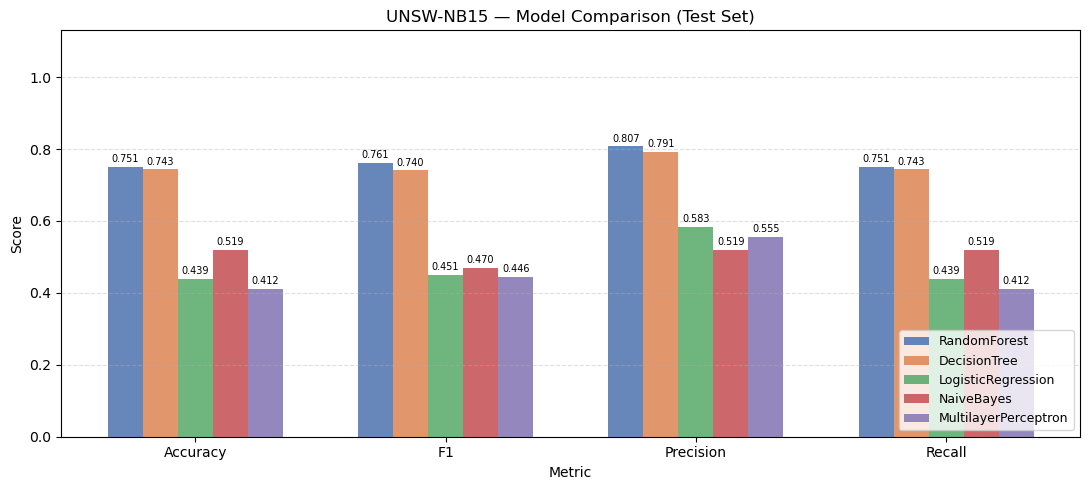

Chart saved → model_comparison.png


In [16]:
chart_metrics = ["Accuracy", "F1", "Precision", "Recall"]
model_names   = list(results.keys())
n_models      = len(model_names)
x             = np.arange(len(chart_metrics))
width         = 0.7 / n_models
palette       = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(model_names, palette)):
    vals = [results[name][m] for m in chart_metrics]
    bars = ax.bar(x + i * width - (n_models - 1) * width / 2,
                  vals, width, label=name, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("UNSW-NB15 — Model Comparison (Test Set)")
ax.set_xticks(x)
ax.set_xticklabels(chart_metrics)
ax.set_ylim(0, 1.13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ml/model_comparison.png", dpi=150)
plt.show()
print("Chart saved → model_comparison.png")

## 15 · Save Best Full-Pipeline to HDFS

In [17]:
"""best_name = max(results, key=lambda x: (
    results[x]["F1"], 
    results[x]["Precision"], 
    results[x]["Recall"], 
    results[x]["Accuracy"]
))
"""

'best_name = max(results, key=lambda x: (\n    results[x]["F1"], \n    results[x]["Precision"], \n    results[x]["Recall"], \n    results[x]["Accuracy"]\n))\n'

In [18]:
# Initialisation des scores globaux à 0 pour chaque modèle
model_scores = {name: 0 for name in results.keys()}
chart_metrics = ["Accuracy", "F1", "Precision", "Recall"]

for metric in chart_metrics:
    # On trie les modèles du moins bon au meilleur pour cette métrique précise
    # Le premier aura 1 point, le deuxième 2 points, etc.
    sorted_models = sorted(results.keys(), key=lambda x: results[x][metric])
    
    for rank, name in enumerate(sorted_models, 1):
        model_scores[name] += rank

# Le gagnant est celui qui a accumulé le plus de points
best_name = max(model_scores, key=model_scores.get)

print(f"Scores totaux : {model_scores}")
print(f"Le meilleur modèle est : {best_name}")


Scores totaux : {'RandomForest': 20, 'DecisionTree': 16, 'LogisticRegression': 9, 'NaiveBayes': 10, 'MultilayerPerceptron': 5}
Le meilleur modèle est : RandomForest


In [19]:
"""best_name = max(results, key=lambda x: results[x]["F1"])
print(f"Best model : {best_name}  (F1={results[best_name]['F1']:.4f})")"""

'best_name = max(results, key=lambda x: results[x]["F1"])\nprint(f"Best model : {best_name}  (F1={results[best_name][\'F1\']:.4f})")'

In [20]:


best_clf = eval_models[best_name]

# The saved pipeline = feature stages + label_indexer + best classifier
# When loaded, it takes raw (preprocessed) data → outputs 'label' + 'prediction'
final_stages        = feat_model.stages + [label_model, best_clf]
full_pipeline_model = PipelineModel(stages=final_stages)

full_pipeline_model.write().overwrite().save(MODEL_PATH)
print(f"✅  Full pipeline saved to {MODEL_PATH}")
print(f"   Stages: {[type(s).__name__ for s in full_pipeline_model.stages]}")

✅  Full pipeline saved to hdfs://namenode:9005/ml/unsw_nb15_final_pipeline
   Stages: ['StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'OneHotEncoderModel', 'OneHotEncoderModel', 'OneHotEncoderModel', 'VectorAssembler', 'StandardScalerModel', 'StringIndexerModel', 'RandomForestClassificationModel']


## 16 · Verify Saved Model

In [21]:
print(f"Loading model from: {MODEL_PATH}")
try:
    loaded = PipelineModel.load(MODEL_PATH)
    print(f"✅ Loaded — {len(loaded.stages)} stages:")
    for s in loaded.stages:
        print(f"   • {type(s).__name__}")

    # df_test_clean already has attack_cat (needed by label_indexer inside pipeline)
    # and does NOT have the binary label column (dropped in preprocess)
    preds = loaded.transform(df_test_clean.limit(20))

    # Columns available after pipeline: all original + idx/vec/features/scaledFeatures/label/prediction/probability
    show_cols = [TARGET_RAW, LABEL_COL, "prediction", "probability"]
    print("\nSample predictions:")
    preds.select(show_cols).show(truncate=False)
    print("🚀 Verification complete.")
except Exception as e:
    print(f"❌ Verification failed: {e}")

Loading model from: hdfs://namenode:9005/ml/unsw_nb15_final_pipeline
✅ Loaded — 10 stages:
   • StringIndexerModel
   • StringIndexerModel
   • StringIndexerModel
   • OneHotEncoderModel
   • OneHotEncoderModel
   • OneHotEncoderModel
   • VectorAssembler
   • StandardScalerModel
   • StringIndexerModel
   • RandomForestClassificationModel

Sample predictions:
+----------+-----+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|attack_cat|label|prediction|probability                                                                                                                                                                                                       |
+----------+-----+----------+------------------------------------------------------------------------------------------------------------------------------

## 17 · Stop Spark

In [22]:
spark.stop()
print('Spark stopped.')

Spark stopped.
